# LDSTOP Method: Applied to observables of Markov diffusion processes

This notebook accompanies the article **Stochastic optimisation method for estimating large deviations**.  
It demonstrates how the LDSTOP method can be used to estimate the large deviations of general observables of Markov diffusion processes.

**Author:** Daniël W. H. Cloete  
**Date:** September 2026  
**Environment:** Python 3.12.3 (see `requirements.txt` / `runtime.txt`)

### Required packages download

In [ ]:
%pip install -r ../requirements.txt

### Imports

In [1]:
# plotting
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
colors = ['#1f77b4', '#318c31', '#d62728']

# general
import numpy as np
import copy
from tqdm import tqdm

# torch
import torch
from torch import nn
from torch.distributions import Normal
torch.set_default_dtype(torch.float64)

### LDSTOP method

In [3]:
def ldstop_MarkovDiffusion(F, sigma, F_theta, x0, f, g, k_min, k_max, delta_k, n, delta_t, T, N, M, alpha):
    """
    Parameters:
        F             (function):     original process drift
        sigma         (float):        original process noise matrix
        F_theta       (torch.nn):     controlled process drift
        x0            (float list):   initial state
        f             (function):     density-type function in observable definition
        g             (function):     current-type function in observable definition
        k_min         (float):        minimum k value
        k_max         (float):        maximum k value
        delta_k       (float):        k value increment
        n             (int):          number of independent parallel trajectories per epoch
        delta_t       (float):        time increment size
        T             (int):          final time for each trajectory
        N             (int):          number of optimization epochs per k value
        M             (int):          number of final epochs estimates to construct final approximations
        alpha         (float):        initial learning rate for Adagrad optimizer

    Returns:
        I_est      (float array):           final rate function estimates
        A_est      (float array):           final observable value estimates
        SCGF_est   (float array):           final SCGF estimates
        ks         (float array):           corresponding k values
        theta_star (torch.state_dict list): optimal parameter values
        As         (float array):           observable estimates over each optimization
        Ks         (float array):           KL divergence estimates over each optimization
        Ls         (float array):           loss estimates over each optimization
    """
    # number of k values
    num_ks = int(round(k_max/delta_k, 10)) + int(round(-k_min/delta_k, 10)) + 1
    # final estimate arrays
    I_est, A_est, SCGF_est, ks = np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks)
    theta_star = []
    # estimate tracking arrays
    As, Ks, Ls = np.zeros((num_ks, N)), np.zeros((num_ks, N)), np.zeros((num_ks, N))

    # initial k value
    k = 0
    k_index = 0

    # initial state
    x = torch.tensor(x0).repeat(n,1)

    # time array and dW
    ts = torch.arange(0.0, T + delta_t, delta_t)
    dW = Normal(0, torch.sqrt(ts[1]))

    # progress bar
    with tqdm(total=num_ks * N) as pbar:
        # k = 0 and positive k loop
        while k <= k_max:
            # adagrad optimizer for theta
            optimizer = torch.optim.Adagrad(F_theta.parameters(), lr = alpha)

            for epoch in range(N):
                # array to track trajectories
                X_t = torch.zeros(len(ts), n, x.shape[1])
                strat_integral = torch.zeros(n, x.shape[1])

                # detach state from previous epochs
                x = x.detach()
                X_t[0] = x

                # generate n independent parallel trajectories using theta
                for i in range(1, len(ts)):
                    F_theta_x = F_theta(x)
                    dx = F_theta_x * delta_t + sigma * dW.sample((n,len(x[0])))
                    x1 = x + dx
                    strat_integral += g((x + x1) / 2) * dx
                    x = x1
                    X_t[i] = x

                # observable, KL divergence, loss estimates
                A_T = f(X_t).mean() + (strat_integral/T).mean()
                K_T = (1 / (2 * sigma ** 2)) * ((F_theta(X_t) - F(X_t)) ** 2).sum(2).mean()
                L_T = K_T - k * A_T

                # stoch autodiff
                loss = L_T
                loss.backward()

                # SGD steps
                optimizer.step()
                optimizer.zero_grad()

                # record estimates
                As[k_index, epoch] = A_T.detach()
                Ks[k_index, epoch] = K_T.detach()
                Ls[k_index, epoch] = L_T.detach()

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star.append(copy.deepcopy(F_theta.state_dict()))

            # increment k
            k += delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

        # reinitialize k, theta, x
        k = -delta_k
        F_theta.load_state_dict(theta_star[0])
        x = torch.tensor(x0).repeat(n,1)

        # negative k loop
        while k >= k_min:
            # adagrad optimizer for theta
            optimizer = torch.optim.Adagrad(F_theta.parameters(), lr = alpha)

            for epoch in range(N):
                # array to track trajectories
                X_t = torch.zeros(len(ts), n, x.shape[1])
                strat_integral = torch.zeros(n, x.shape[1])

                # detach state from previous epochs
                x = x.detach()
                X_t[0] = x

                # generate n independent parallel trajectories using theta
                for i in range(1, len(ts)):
                    F_theta_x = F_theta(x)
                    dx = F_theta_x * delta_t + sigma * dW.sample((n,len(x[0])))
                    x1 = x + dx
                    strat_integral += g((x + x1) / 2) * dx
                    x = x1
                    X_t[i] = x

                # observable, KL divergence, loss estimates
                A_T = f(X_t).mean() + (strat_integral/T).mean()
                K_T = (1 / (2 * sigma ** 2)) * ((F_theta(X_t) - F(X_t)) ** 2).sum(2).mean()
                L_T = K_T - k * A_T

                # stoch autodiff
                loss = L_T
                loss.backward()

                # SGD steps
                optimizer.step()
                optimizer.zero_grad()

                # record estimates
                As[k_index, epoch] = A_T.detach()
                Ks[k_index, epoch] = K_T.detach()
                Ls[k_index, epoch] = L_T.detach()

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star.append(copy.deepcopy(F_theta.state_dict()))

            # decrement k
            k -= delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

    return I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls

### Results plotting function

In [4]:
def plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I = 0, SCGF = 0):
    # figure and subplots
    fig, axs = plt.subplots(3, 2, figsize=(9, 9))
    ax1, ax2 = axs[0]
    ax3, ax4 = axs[1]
    ax5, ax6 = axs[2]

    # rate function
    ax1.scatter(A_est, I_est, color=colors[2], marker='x', zorder=2)
    if I != 0:
        a_plot = np.linspace(np.min(A_est), np.max(A_est), 1000)
        ax1.plot(a_plot, I(a_plot), color='black', zorder=1)
    ax1.set_xlabel(r'$a$')
    ax1.set_ylabel(r'$I(a)$')
    ax1.spines['bottom'].set_position(('data', 0))
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # scaled cumulant generating function
    k_min = np.min(ks)
    k_max = np.max(ks)
    ax2.scatter(ks, SCGF_est, color=colors[0], marker='x', zorder=2)
    if SCGF != 0:
        k_plot = np.linspace(k_min, k_max, 1000)
        ax2.plot(k_plot, SCGF(k_plot), color='black', zorder=1)
    ax2.set_xlabel(r'$k$')
    ax2.set_ylabel(r'$\lambda(k)$')
    ax2.spines['bottom'].set_position(('data', 0))
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    col_i = [0 if k == 0 else 1 if k > 0 else 2 for k in ks]
    alphs = [1 if k == 0 else k/k_max if k > 0 else k/k_min for k in ks]

    # observable and KL estimates
    epochs = np.arange(1, len(As[0])+1)
    for i in range(len(As)):
        ax3.plot(epochs, As[i], color=colors[col_i[i]], alpha=alphs[i])
        ax4.plot(epochs, Ks[i], color=colors[col_i[i]], alpha=alphs[i])
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel(r'$A_T$')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel(r'$K_T$')

    # loss and scaled loss
    for i in range(len(As)):
        ax5.plot(epochs, Ls[i], color=colors[col_i[i]], alpha=alphs[i])
        ax6.plot(epochs, Ls[i] + SCGF_est[i], color=colors[col_i[i]], alpha=alphs[i])
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel(r'$L_T$')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel(r'Scaled $L_T$')

    fig.tight_layout(w_pad=3, rect=[0, 0, 1, 0.96])
    phi = (1 + np.sqrt(5)) / 2
    for ax in axs.flat:
        ax.set_box_aspect(1 / phi)
    return fig

### Ornstein-Uhlenbeck quadratic observable

100%|██████████| 375/375 [04:28<00:00,  1.40it/s]


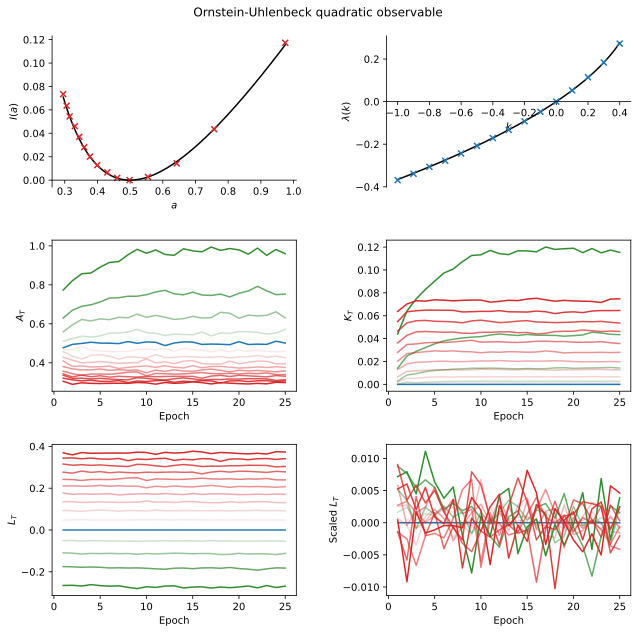

In [5]:
# problem parameters
gamma = 1.0
sigma = 1.0

def F(x):
    return -gamma * x

def f(x):
    return x**2

def g(x):
    return 0*x

# algorithm parameters
class LinearDrift1D(nn.Module):
    def __init__(self):
        super(LinearDrift1D, self).__init__()
        self.m = nn.Parameter(torch.zeros(1))
        self.c = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return F(x) + self.m*x + self.c

F_theta = LinearDrift1D()
x0 = 0.0
k_min = -1
k_max = 0.4
delta_k = 0.1
n = 1000
delta_t = 0.01
T = 10
N = 25
M = 10
alpha = 0.05

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls = ldstop_MarkovDiffusion(F, sigma, F_theta, x0, f, g, k_min, k_max, delta_k, n, delta_t, T, N, M, alpha)

# true functions
def I(a):
    return (gamma**2 * a) / (2*sigma**2) + (sigma**2) / (8*a) - (gamma/2)

def SCGF(k):
    return (gamma/2) - (1/2)*np.sqrt(gamma**2 - 2 * sigma**2 * k)

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Ornstein-Uhlenbeck quadratic observable')
plt.show()

### 2D linear diffusion nonequilibrium work

100%|██████████| 195/195 [08:27<00:00,  2.60s/it]


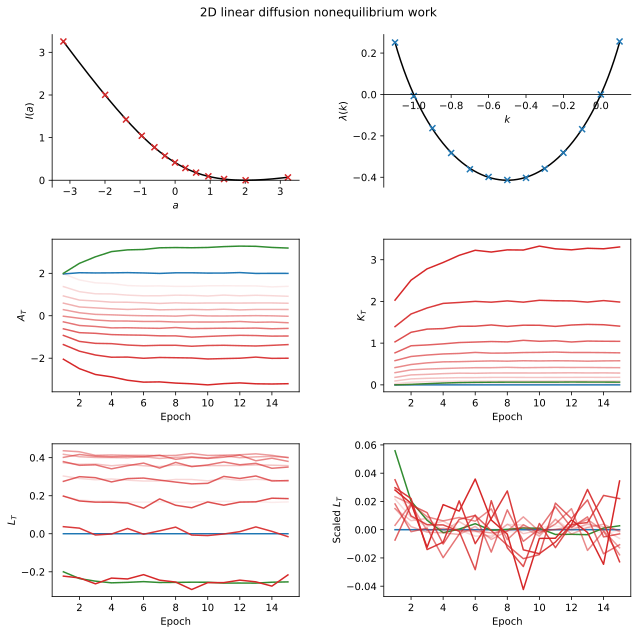

In [6]:
# problem parameters
gamma = 1.0
xi = 1.0
sigma = 1.0

C = (2/(sigma**2))*torch.tensor([[gamma, xi], [-xi, gamma]])
C = (C - C.T)

M_mat = torch.tensor([[gamma, xi], [-xi, gamma]])
def F(x):
    return -torch.matmul(x, M_mat.T)

def f(x):
    return 0*x

def g(x):
    return -torch.matmul(x, C.T)

# algorithm parameters
class LinearDrift2D(nn.Module):
    def __init__(self):
        super(LinearDrift2D, self).__init__()
        self.theta = nn.Parameter(torch.zeros(2, 2))

    def forward(self, x):
        return F(x) + torch.matmul(x, self.theta.T)

class NeuralDrift2D(nn.Module):
    def __init__(self):
        super(NeuralDrift2D, self).__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 2)
        self.act = torch.nn.SiLU()

    def forward(self, s):
        x = self.act(self.fc1(s))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return F(x) + x

F_theta = LinearDrift2D()
# F_theta = NeuralDrift()
x0 = [0.0, 0.0]
k_min = -1.1
k_max = 0.1
delta_k = 0.1
n = 1000
delta_t = 0.01
T = 15
N = 15
M = 10
alpha = 0.1

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls = ldstop_MarkovDiffusion(F, sigma, F_theta, x0, f, g, k_min, k_max, delta_k, n, delta_t, T, N, M, alpha)

# true functions
def k_a(a):
    return np.where(a > 0,
        -(a**2*xi**2 + 4*xi**4 - np.sqrt(a**2 * xi**2 * (a**2 + 4*xi**2) * (gamma**2 + xi**2)))/(2*a**2*xi**2 + 8*xi**4),
        -(a**2*xi**2 + 4*xi**4 + np.sqrt(a**2 * xi**2 * (a**2 + 4*xi**2) * (gamma**2 + xi**2)))/(2*a**2*xi**2 + 8*xi**4)
    )

def SCGF(k):
    return (gamma - np.sqrt(gamma**2 - 4*k*(k+1)*xi**2))

def I(a):
    return k_a(a)*a - SCGF(k_a(a))

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('2D linear diffusion nonequilibrium work')
plt.show()